<a href="https://colab.research.google.com/github/Prachi-Nigade/California-House-Price-Prediction/blob/main/California_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Calofornia House Price Prediction Model Project

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
#Load the data

In [31]:
df=pd.read_csv('/content/housing_with_price.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,price
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200,342200
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700,84700


In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [28]:
#check data info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [29]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.sample(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18754,-122.36,40.69,32,3611,772.0,2060,759,1.7427,INLAND,60600
4796,-118.35,34.03,43,2122,524.0,1510,436,2.2273,<1H OCEAN,123300
17477,-120.05,34.47,21,1241,248.0,746,211,3.8056,NEAR OCEAN,425000
10947,-117.87,33.76,6,2992,1194.0,3800,1130,2.2460,<1H OCEAN,183300
10999,-117.79,33.76,25,2037,252.0,796,249,11.0546,<1H OCEAN,487200
14107,-117.11,32.75,46,695,182.0,601,195,2.4219,NEAR OCEAN,90600
5802,-118.25,34.14,30,1615,570.0,1245,544,1.8929,<1H OCEAN,196900
16558,-121.28,37.83,32,696,151.0,443,144,2.5156,INLAND,86300
11004,-117.81,33.75,25,2365,471.0,1197,458,3.7031,<1H OCEAN,227800
1806,-122.34,37.93,32,2389,652.0,1672,584,1.4423,NEAR BAY,88300


In [8]:
#detecting missing values
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
ocean_proximity,0
median_house_value,0


In [9]:
# Filling missing value
df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)

/tmp/ipython-input-441/301207498.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)


In [10]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0
median_house_value,0


In [12]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')

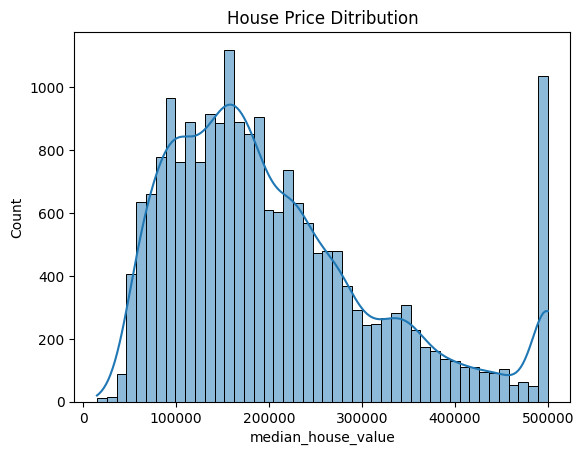

In [13]:
# EDA :
sns.histplot(df['median_house_value'],kde=True)
plt.title('House Price Ditribution')
plt.show()

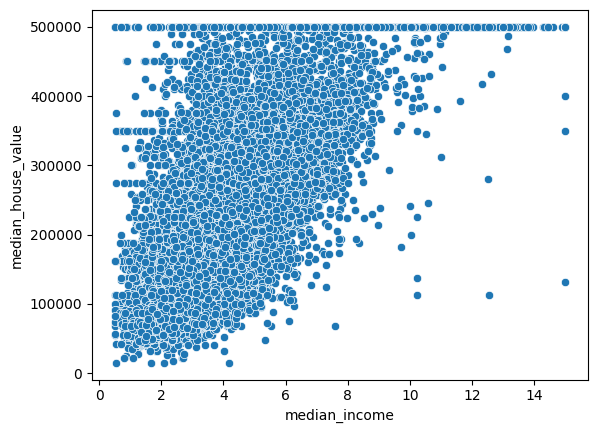

In [14]:
# Feature relationship:
sns.scatterplot(x='median_income',y='median_house_value',data=df)
plt.show()

In [15]:
# Feature and target spliting
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']

In [16]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [18]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [19]:
!apt-get install graphviz -y
!pip install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


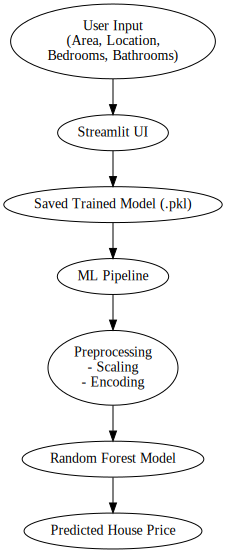

In [20]:
from graphviz import Digraph

# Create flow diagram
dot = Digraph(format='png')
dot.attr(rankdir='TB', size='10,12')

dot.node('A', 'User Input\n(Area, Location,\nBedrooms, Bathrooms)')
dot.node('B', 'Streamlit UI')
dot.node('C', 'Saved Trained Model (.pkl)')
dot.node('D', 'ML Pipeline')
dot.node('E', 'Preprocessing\n- Scaling\n- Encoding')
dot.node('F', 'Random Forest Model')
dot.node('G', 'Predicted House Price')
dot.edges([
    ('A', 'B'),
    ('B', 'C'),
    ('C', 'D'),
    ('D', 'E'),
    ('E', 'F'),
    ('F', 'G')
])

dot


In [21]:
dot.render('house_price_architecture')

'house_price_architecture.png'

In [22]:
correlation_matrix = df.corr(numeric_only=True)


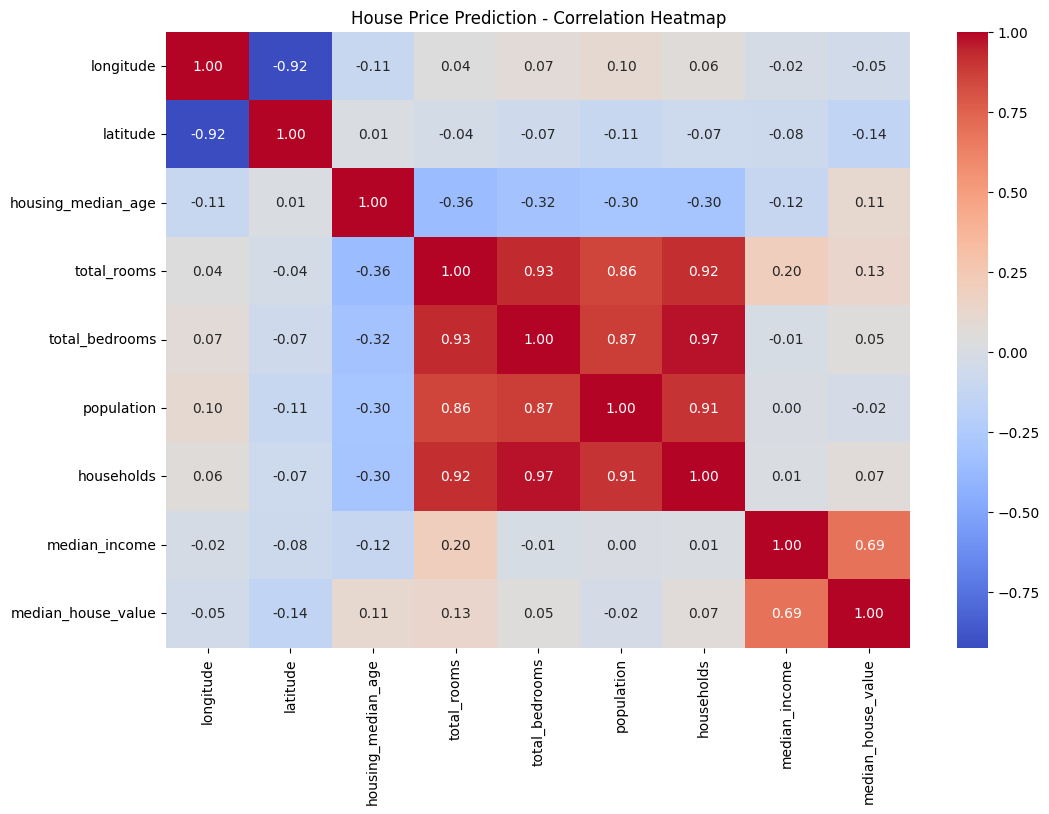

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("House Price Prediction - Correlation Heatmap")
plt.show()


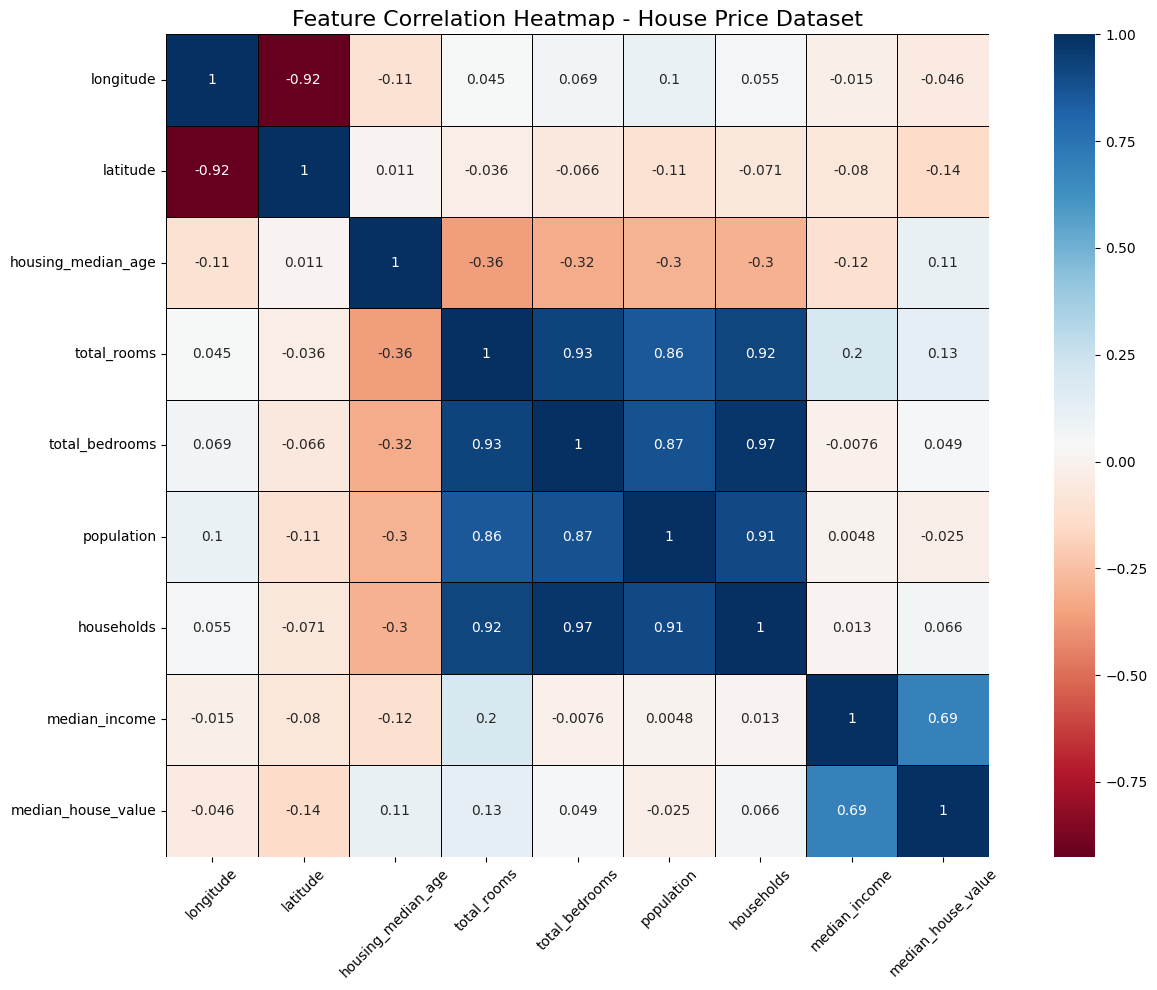

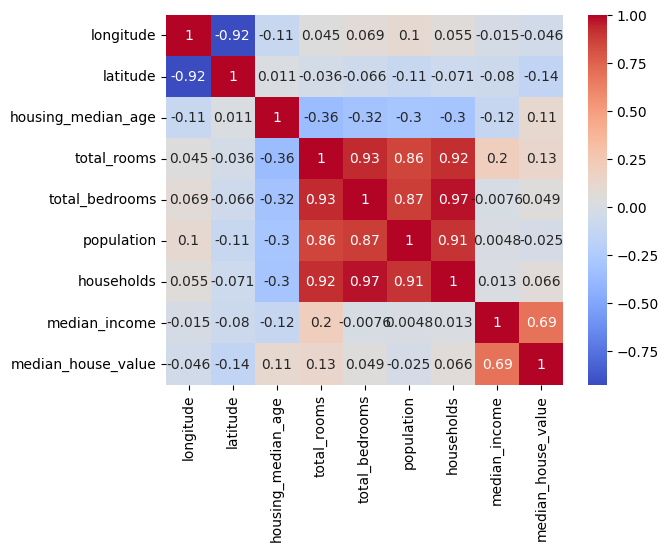

In [24]:
plt.figure(figsize=(14,10))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='RdBu',
            linewidths=0.5,
            linecolor='black',
            square=True)

plt.title("Feature Correlation Heatmap - House Price Dataset",
          fontsize=16)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.savefig("househeatmap.png", dpi=300, bbox_inches='tight')
plt.show()


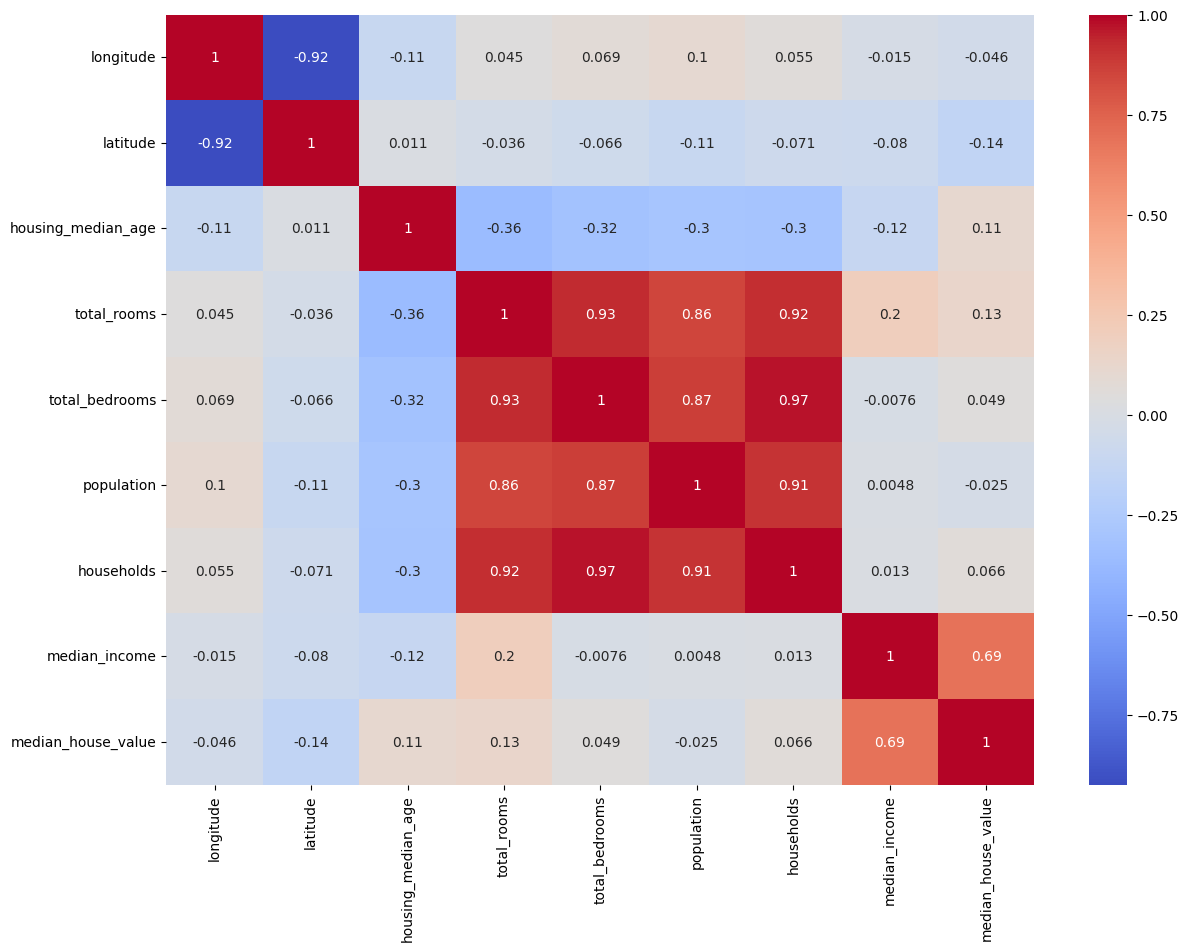

In [25]:
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [46]:
#separate features (x) and target (y)
x = df.drop(['price', 'median_house_value'], axis=1)
y = df['price']

In [33]:
#Train Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [39]:
print(x_train.shape)
print(x_test.shape)



(16512, 10)
(4128, 10)


In [47]:
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough'
)

# Create the full pipeline with preprocessing and the model
full_pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the Model
full_pipeline_lr.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [50]:
y_pred =  full_pipeline_lr.predict(x_test)

In [51]:
print("R2 Score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 1.0
MSE: 6.388875788662445e-19
RMSE: 7.993044344092208e-10


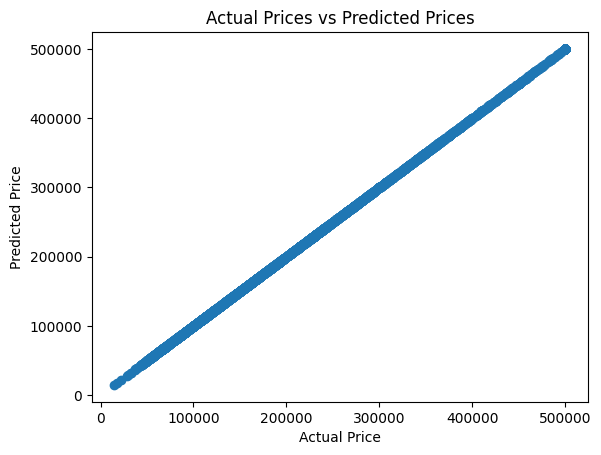

In [52]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()